[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/workshops/workshop-04-regresion-multiple-seleccion-variables.ipynb)

## 2. Importación de librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3. Importación del conjunto de datos

In [ ]:
dataset = pd.read_csv("https://raw.githubusercontent.com/Laverde97/phd-data-science-ai/main/semesters/semester-01/machine-learning/data/regresion-multiple/dataset_regresion_multiple.csv")
dataset

,Edad,Experiencia_Anios,Horas_Trabajo_Semanal,Nivel_Educacion,Num_Proyectos,Certificaciones,Genero,Ciudad,Salario
0,56,0,37.3,3,12,8,F,Medellín,7985.65
1,69,9,32.9,2,12,5,M,Medellín,8163.18
2,46,35,49.3,2,23,3,M,Cali,10424.51
3,32,8,42.6,4,23,4,F,Cali,9633.28
4,60,31,28.5,2,13,6,M,Cali,9049.57
...,...,...,...,...,...,...,...,...,...
4995,24,9,46.2,4,12,5,F,Medellín,8593.88
4996,66,26,41.0,3,14,1,M,Bogotá,10929.33
4997,26,8,38.5,3,8,9,M,Barranquilla,6630.02
4998,53,27,40.1,3,15,9,F,Cali,11681.67


In [ ]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 8].values

### Contenido de la variable X

In [ ]:
print("=" * 60)
print("Datos en X")
print("=" * 60)
print(X)

Datos en X
[[56 0 37.3 ... 8 'F' 'Medellín']
 [69 9 32.9 ... 5 'M' 'Medellín']
 [46 35 49.3 ... 3 'M' 'Cali']
 ...
 [26 8 38.5 ... 9 'M' 'Barranquilla']
 [53 27 40.1 ... 9 'F' 'Cali']
 [36 0 42.0 ... 7 'F' 'Barranquilla']]


### Contenido de la variable y

In [ ]:
print("=" * 60)
print("Datos en y")
print("=" * 60)
print(y)

Datos en y
[ 7985.65  8163.18 10424.51 ...  6630.02 11681.67  8418.36]


## Dimensiones y estructura del dataset
Cantidad de registros y columnas.

In [ ]:
# ============================================================
# 2. DIMENSIONES Y ESTRUCTURA DEL CONJUNTO DE DATOS
# ============================================================

print("DIMENSIONES DEL CONJUNTO DE DATOS")
print("=" * 60)

print(f"Número de registros : {dataset.shape[0]:,}")
print(f"Número de columnas  : {dataset.shape[1]}")

print("\nNOMBRES DE LAS COLUMNAS")
print("=" * 60)

print(list(dataset.columns))

DIMENSIONES DEL CONJUNTO DE DATOS
Número de registros : 5,000
Número de columnas  : 9

NOMBRES DE LAS COLUMNAS
['Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones', 'Genero', 'Ciudad', 'Salario']


## Tipos de variables

In [ ]:
# ============================================================
# 3. TIPOS DE DATOS
# ============================================================

print("TIPOS DE DATOS")
print("=" * 60)

display(
    dataset.dtypes
           .rename("Tipo de dato")
           .to_frame()
)

TIPOS DE DATOS


,Tipo de dato
Edad,int64
Experiencia_Anios,int64
Horas_Trabajo_Semanal,float64
Nivel_Educacion,int64
Num_Proyectos,int64
Certificaciones,int64
Genero,object
Ciudad,object
Salario,float64


## Identificación de valores faltantes

Verificación general de datos faltantes

In [ ]:
# Verificar si existe al menos un valor faltante en el dataset
hay_nulos = dataset.isnull().values.any()

print("¿El conjunto de datos contiene valores nulos?")
print("=" * 60)

print("Sí" if hay_nulos else "No")

¿El conjunto de datos contiene valores nulos?
No


In [ ]:
# ============================================================
# 4. IDENTIFICACIÓN DE VALORES NULOS
# ============================================================

valores_faltantes = dataset.isnull().sum()

tabla_faltantes = pd.DataFrame({
    'Variable': valores_faltantes.index,
    'Valores nulos': valores_faltantes.values
})

print("VALORES NULOS POR VARIABLE")
print("=" * 60)

display(tabla_faltantes)

VALORES NULOS POR VARIABLE


,Variable,Valores nulos
0,Edad,0
1,Experiencia_Anios,0
2,Horas_Trabajo_Semanal,0
3,Nivel_Educacion,0
4,Num_Proyectos,0
5,Certificaciones,0
6,Genero,0
7,Ciudad,0
8,Salario,0



## 4. Exploración gráfica de las variables numéricas

Se observa gráficamente la relación entre cada gasto y la **Ganancia**, sin modificar el procedimiento del modelo.


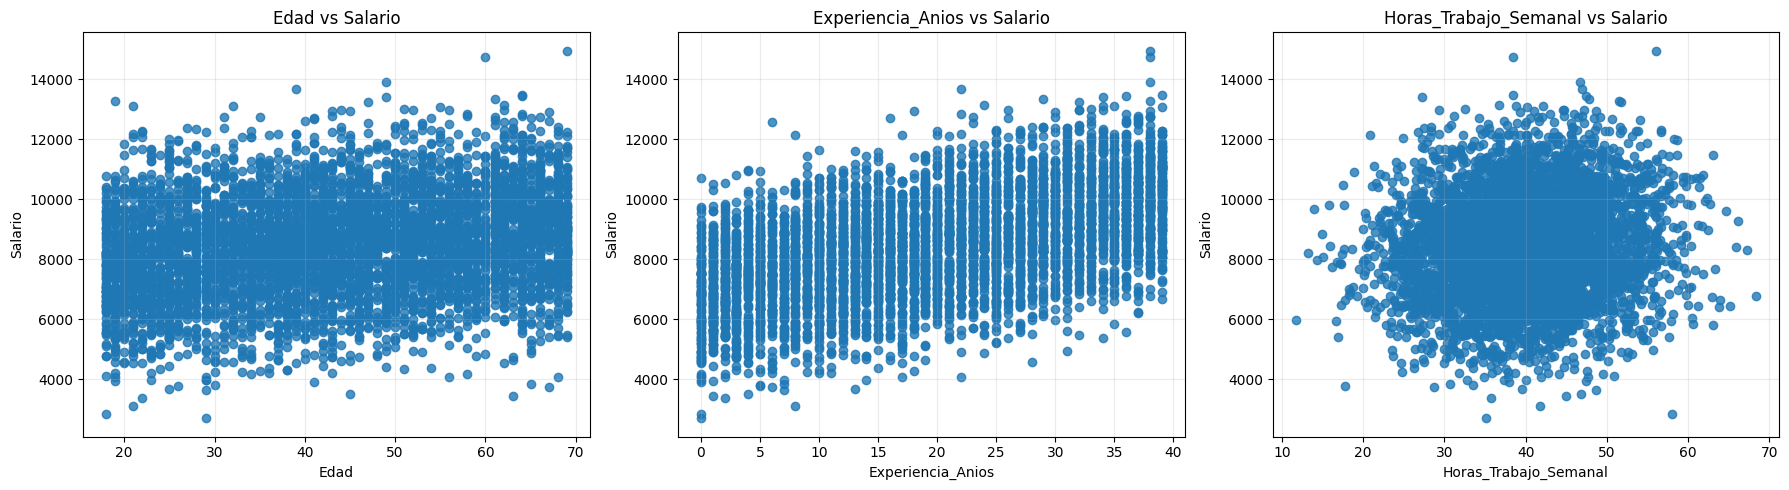

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = ['Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal']

for ax, variable in zip(axes, variables):
    ax.scatter(dataset[variable], dataset['Salario'], alpha=0.8)
    ax.set_title(f'{variable} vs Salario')
    ax.set_xlabel(variable)
    ax.set_ylabel('Salario')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 5. Conversión de la variable categórica a variables dummy

La variable **Ciudad** es categórica. Por esta razón se utiliza `pd.get_dummies()` para transformarla en variables numéricas de 0 y 1, tal como se realizó en clase.

Se utiliza `drop_first=True` para dejar una ciudad como categoría de referencia.


In [ ]:
# Aplicar get_dummies
df_limpio = pd.DataFrame(
    X,
    columns=['Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones', 'Genero', 'Ciudad']
)

df_codificado = pd.get_dummies(
    df_limpio,
    columns=['Genero','Ciudad'],
    drop_first=True
)

# Convertir columnas booleanas a int (1 y 0)
for col in df_codificado.columns:
    if df_codificado[col].dtype == 'bool':
        df_codificado[col] = df_codificado[col].astype(int)

print("--- DATOS CODIFICADOS (SIN REORDENAR) ---")
print("\n")
df_codificado

--- DATOS CODIFICADOS (SIN REORDENAR) ---




,Edad,Experiencia_Anios,Horas_Trabajo_Semanal,Nivel_Educacion,Num_Proyectos,Certificaciones,Genero_M,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín
0,56,0,37.3,3,12,8,0,0,0,1
1,69,9,32.9,2,12,5,1,0,0,1
2,46,35,49.3,2,23,3,1,0,1,0
3,32,8,42.6,4,23,4,0,0,1,0
4,60,31,28.5,2,13,6,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
4995,24,9,46.2,4,12,5,0,0,0,1
4996,66,26,41.0,3,14,1,1,1,0,0
4997,26,8,38.5,3,8,9,1,0,0,0
4998,53,27,40.1,3,15,9,0,0,1,0


### Orden de las variables codificadas

In [ ]:
# Identificar columnas dummy de Ciudad
columnas_Ciudad = [
    col for col in df_codificado.columns
    if col.startswith('Ciudad_')
]

# Identificar columnas dummy de Genero
columnas_Genero = [
    col for col in df_codificado.columns
    if col.startswith('Genero_')
]

# Identificar columnas numéricas
columnas_numericas = ['Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones']

# Primero las variables dummy de Ciudad y luego las variables numéricas
nuevo_orden = columnas_Genero + columnas_Ciudad + columnas_numericas

# Reordenar el DataFrame
df_codificado = df_codificado[nuevo_orden]

print("--- DATOS CODIFICADOS ---")
X = df_codificado
X

--- DATOS CODIFICADOS ---


,Genero_M,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín,Edad,Experiencia_Anios,Horas_Trabajo_Semanal,Nivel_Educacion,Num_Proyectos,Certificaciones
0,0,0,0,1,56,0,37.3,3,12,8
1,1,0,0,1,69,9,32.9,2,12,5
2,1,0,1,0,46,35,49.3,2,23,3
3,0,0,1,0,32,8,42.6,4,23,4
4,1,0,1,0,60,31,28.5,2,13,6
...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,1,24,9,46.2,4,12,5
4996,1,1,0,0,66,26,41.0,3,14,1
4997,1,0,0,0,26,8,38.5,3,8,9
4998,0,0,1,0,53,27,40.1,3,15,9



## 6. Separación del conjunto de entrenamiento y prueba

Se utiliza la misma división de clase:

- **80 %** para entrenamiento.
- **20 %** para prueba.
- `random_state = 0`.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

### Datos de entrenamiento

In [ ]:
X_train.head()

,Genero_M,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín,Edad,Experiencia_Anios,Horas_Trabajo_Semanal,Nivel_Educacion,Num_Proyectos,Certificaciones
2913,1,0,0,0,34,3,35.0,3,16,7
3275,0,1,0,0,43,13,42.4,2,21,4
775,0,0,0,1,67,19,28.9,3,7,4
217,1,0,1,0,66,2,42.6,3,3,1
1245,0,1,0,0,44,5,36.6,2,18,5


## Dimensiones y estructura del X_train
Cantidad de registros y columnas.

In [ ]:
# ============================================================
# 2. DIMENSIONES Y ESTRUCTURA DEL CONJUNTO DE DATOS
# ============================================================

print("DIMENSIONES DEL CONJUNTO DE DATOS")
print("=" * 60)

print(f"Número de registros : {X_train.shape[0]:,}")
print(f"Número de columnas  : {X_train.shape[1]}")

print("\nNOMBRES DE LAS COLUMNAS")
print("=" * 60)

print(list(X_train.columns))

DIMENSIONES DEL CONJUNTO DE DATOS
Número de registros : 4,000
Número de columnas  : 10

NOMBRES DE LAS COLUMNAS
['Genero_M', 'Ciudad_Bogotá', 'Ciudad_Cali', 'Ciudad_Medellín', 'Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones']


In [ ]:
y_train

array([ 7699.69,  9793.79,  7249.95, ...,  8009.78, 10319.22,  9778.39])

## 7. Ajuste del modelo de regresión lineal múltiple

In [ ]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
X_train

,Genero_M,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín,Edad,Experiencia_Anios,Horas_Trabajo_Semanal,Nivel_Educacion,Num_Proyectos,Certificaciones
2913,1,0,0,0,34,3,35.0,3,16,7
3275,0,1,0,0,43,13,42.4,2,21,4
775,0,0,0,1,67,19,28.9,3,7,4
217,1,0,1,0,66,2,42.6,3,3,1
1245,0,1,0,0,44,5,36.6,2,18,5
...,...,...,...,...,...,...,...,...,...,...
4931,0,0,1,0,42,10,29.7,3,20,6
3264,0,0,0,0,32,28,39.4,3,21,6
1653,0,1,0,0,41,27,42.3,3,10,1
2607,0,0,1,0,39,27,36.0,4,18,8


In [ ]:
# ============================================================
# 2. DIMENSIONES Y ESTRUCTURA DEL CONJUNTO DE DATOS
# ============================================================

print("DIMENSIONES DEL CONJUNTO DE DATOS")
print("=" * 60)

print(f"Número de registros : {X_train.shape[0]:,}")
print(f"Número de columnas  : {X_train.shape[1]}")

print("\nNOMBRES DE LAS COLUMNAS")
print("=" * 60)

print(list(X_train.columns))

DIMENSIONES DEL CONJUNTO DE DATOS
Número de registros : 4,000
Número de columnas  : 10

NOMBRES DE LAS COLUMNAS
['Genero_M', 'Ciudad_Bogotá', 'Ciudad_Cali', 'Ciudad_Medellín', 'Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones']


## 8. Predicción sobre el conjunto de prueba

In [ ]:
y_pred = regressor.predict(X_test)

### Comparación entre los valores reales y los valores predichos

In [ ]:
for i in range(len(y_test)):
    print(
        y_test[i],
        '----------->',
        round(y_pred[i], 2),
        'Diferencia',
        round((y_test[i] - y_pred[i]), 2),
        '--- Porcentaje-----',
        round(((1 - (y_test[i] / y_pred[i])) * 100), 2),
        '%'
    )

6900.54 -----------> 6804.76 Diferencia 95.78 --- Porcentaje----- -1.41 %
9634.17 -----------> 11080.56 Diferencia -1446.39 --- Porcentaje----- 13.05 %
8755.02 -----------> 8962.13 Diferencia -207.11 --- Porcentaje----- 2.31 %
9942.12 -----------> 9784.21 Diferencia 157.91 --- Porcentaje----- -1.61 %
9698.54 -----------> 9386.21 Diferencia 312.33 --- Porcentaje----- -3.33 %
8499.07 -----------> 8705.39 Diferencia -206.32 --- Porcentaje----- 2.37 %
8436.92 -----------> 8817.44 Diferencia -380.52 --- Porcentaje----- 4.32 %
7188.37 -----------> 8164.64 Diferencia -976.27 --- Porcentaje----- 11.96 %
8828.02 -----------> 8876.46 Diferencia -48.44 --- Porcentaje----- 0.55 %
9824.2 -----------> 8909.56 Diferencia 914.64 --- Porcentaje----- -10.27 %
6957.1 -----------> 6575.57 Diferencia 381.53 --- Porcentaje----- -5.8 %
8088.29 -----------> 8946.46 Diferencia -858.17 --- Porcentaje----- 9.59 %
8761.44 -----------> 9016.71 Diferencia -255.27 --- Porcentaje----- 2.83 %
8809.5 -----------> 8618.


### Gráfica: valores reales vs. valores predichos

Los puntos más cercanos a la diagonal representan predicciones más próximas a los valores reales.


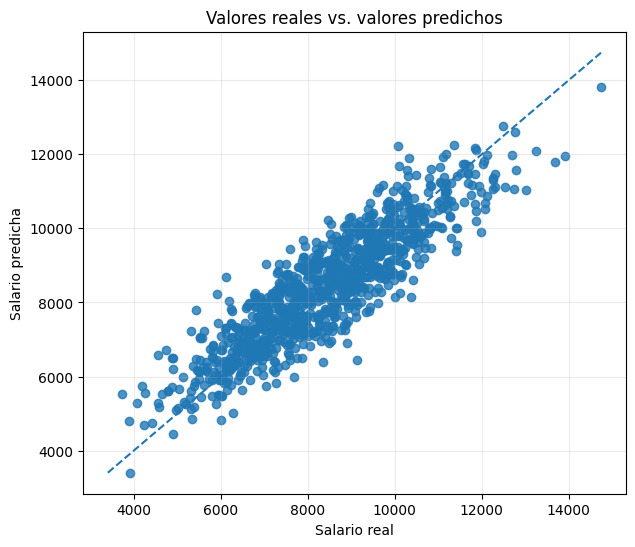

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.8)

limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.xlabel('Salario real')
plt.ylabel('Salario predicha')
plt.title('Valores reales vs. valores predichos')
plt.grid(alpha=0.25)
plt.show()


## 9. Selección de variables con OLS

En los apuntes de clase se utiliza `statsmodels` para evaluar la significancia de las variables.

Primero se incorpora una columna de unos para representar el **intercepto** y se trabaja con un nivel de significancia:

\[
SL=0.05
\]

La selección se realiza eliminando progresivamente la variable con el valor \(P>|t|\) más alto cuando supera 0.05.


In [ ]:
import statsmodels.api as sm

X = np.append(
    arr=np.ones((len(X), 1)).astype(int),
    values=X,
    axis=1
)

# Nivel de significancia
SL = 0.05

X

array([[1, 0, 0, ..., 3, 12, 8],
       [1, 1, 0, ..., 2, 12, 5],
       [1, 1, 0, ..., 2, 23, 3],
       ...,
       [1, 1, 0, ..., 3, 8, 9],
       [1, 0, 0, ..., 3, 15, 9],
       [1, 0, 0, ..., 2, 16, 7]], dtype=object)


### Modelo con todas las variables

El orden de las columnas es:

1. Constante = $x_0$
2. Genero_M = $x_1$
3. Ciudad_Bogotá = $x_2$
4. Ciudad_Cali = $x_3$
5. Ciudad_Medellín = $x_4$
6. Edad = $x_5$
7. Experiencia_Anios = $x_6$
8. Horas_Trabajo_Semanal = $x_7$
9. Nivel_Educacion = $x_8$
10. Num_Proyectos = $x_9$
11. Certificaciones = $x_{10}$


In [ ]:
# Convertir X_opt a array de NumPy
# Constante 'Genero_M', 'Ciudad_Bogotá', 'Ciudad_Cali', 'Ciudad_Medellín', 'Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones
X_opt = np.array(X[:, [0, 1, 2, 3, 4, 5,6,7,8,9,10]])

# Asegurar que los datos sean tipo float
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     1891.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:05:52   Log-Likelihood:                -40444.
No. Observations:                5000   AIC:                         8.091e+04
Df Residuals:                    4989   BIC:                         8.098e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1510.1144     79.732     18.940      0.000    1353.804    1666.425
x1           -10.2234     22.345     -0.458      0.647     -54.030      33.583
x2             0.2043     31.625      0.006      0.995     -61.795      62.204
x3            22.6697     31.403      0.722      0.470     -38.894      84.233
x4            23.2460     31.267      0.743      0.457     -38.051      84.542
x5            23.7159      0.749     31.672      0.000      22.248      25.184
x6            79.5858      0.979     81.278      0.000      77.666      81.505
x7            16.2849      1.371     11.877      0.000      13.597      18.973
x8           492.5266     10.163     48.462      0.000     472.602     512.451
x9           120.1585      1.564     76.816      0.000     117.092     123.225
x10          204.5024      3.906     52.361      0.000     196.846     212.159
==============================================================================
Omnibus:                        0.245   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.885   Jarque-Bera (JB):                0.257
Skew:                           0.017   Prob(JB):                        0.879
Kurtosis:                       2.989   Cond. No.                         468.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


### Modelo con todas las variables

El orden de las columnas es:

- $x_0$= Constante
- $x_1$= Genero_M
- $x_2$= Ciudad_Bogotá
- $x_3$= Ciudad_Cali
- $x_4$= Ciudad_Medellín
- $x_5$= Edad
- $x_6$= Experiencia_Anios
- $x_7$= Horas_Trabajo_Semanal
- $x_8$= Nivel_Educacion
- $x_9$= Num_Proyectos
- $x_{10}$= Certificaciones



## Función

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Nombres correspondientes a las columnas originales de X
nombres = [
    'Constante',
    'Genero_M',
    'Ciudad_Bogotá',
    'Ciudad_Cali',
    'Ciudad_Medellín',
    'Edad',
    'Experiencia_Anios',
    'Horas_Trabajo_Semanal',
    'Nivel_Educacion',
    'Num_Proyectos',
    'Certificaciones'
]

# Crear DataFrame con nombres
X_df = pd.DataFrame(
    np.asarray(X, dtype=float),
    columns=nombres
)

# Nivel de significancia
alpha = 0.05

# Copia para realizar Backward Elimination
X_opt = X_df.copy()

while True:

    # Ajustar modelo
    modelo = sm.OLS(
        endog=y,
        exog=X_opt
    ).fit()

    # Obtener p-values
    p_values = modelo.pvalues

    # No considerar la constante para eliminar
    p_variables = p_values.drop('Constante')

    # Mayor p-value
    p_max = p_variables.max()
    variable_max = p_variables.idxmax()

    # Si el mayor p-value supera 0.05, eliminar variable
    if p_max > alpha:
        print(
            f'Eliminando: {variable_max:<25} '
            f'p-value = {p_max:.4f}'
        )

        X_opt = X_opt.drop(
            columns=variable_max
        )

    else:
        break

print('\nVariables seleccionadas:')
print(list(X_opt.columns))

# Modelo final
modelo_final = sm.OLS(
    endog=y,
    exog=X_opt
).fit()

modelo_final.summary()

Eliminando: Ciudad_Bogotá             p-value = 0.9948
Eliminando: Genero_M                  p-value = 0.6473
Eliminando: Ciudad_Cali               p-value = 0.4059
Eliminando: Ciudad_Medellín           p-value = 0.5401

Variables seleccionadas:
['Constante', 'Edad', 'Experiencia_Anios', 'Horas_Trabajo_Semanal', 'Nivel_Educacion', 'Num_Proyectos', 'Certificaciones']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     3153.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:30:17   Log-Likelihood:                -40445.
No. Observations:                5000   AIC:                         8.090e+04
Df Residuals:                    4993   BIC:                         8.095e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Constante              1514.7898     76.549     19.789      0.000    1364.721    1664.859
Edad                     23.7134      0.748     31.694      0.000      22.247      25.180
Experiencia_Anios        79.6064      0.978     81.365      0.000      77.688      81.525
Horas_Trabajo_Semanal    16.2958      1.371     11.889      0.000      13.609      18.983
Nivel_Educacion         492.6515     10.159     48.495      0.000     472.736     512.567
Num_Proyectos           120.1573      1.563     76.853      0.000     117.092     123.222
Certificaciones         204.6474      3.901     52.455      0.000     196.999     212.296
==============================================================================
Omnibus:                        0.263   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.277
Skew:                           0.017   Prob(JB):                        0.871
Kurtosis:                       2.988   Cond. No.                         444.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
coeficientes = modelo_final.params

ecuacion = f"Salario = {coeficientes['Constante']:.4f}"

for variable, coef in coeficientes.items():

    if variable == 'Constante':
        continue

    signo = '+' if coef >= 0 else '-'

    ecuacion += (
        f" {signo} "
        f"{abs(coef):.4f} × {variable}"
    )

print(ecuacion)

Salario = 1514.7898 + 23.7134 × Edad + 79.6064 × Experiencia_Anios + 16.2958 × Horas_Trabajo_Semanal + 492.6515 × Nivel_Educacion + 120.1573 × Num_Proyectos + 204.6474 × Certificaciones


## La ecuación de la regresion multiple es:

$$
\text{Salario}
=
\beta_0
+ \beta_1(\text{Edad})
+ \beta_2(\text{Experiencia_Anios})
+ \beta_3(\text{Horas_Trabajo_Semanal})
+ \beta_4(\text{Nivel_Educacion})
+ \beta_5(\text{Num_Proyectos})
+ \beta_6(\text{Certificaciones})
$$


Con valores seria:

$$
\text{Salario}
=
1514.7898
+ 23.7134(\text{Edad})
+ 79.6064(\text{Experiencia_Anios})
+ 16.2958(\text{Horas_Trabajo_Semanal})
+ 492.6515(\text{Nivel_Educacion})
+ 120.1573(\text{Num_Proyectos})
+ 204.6474(\text{Certificaciones})
$$

In [ ]:
# Coeficientes del modelo final
coeficientes = modelo_final.params

# Mostrar ecuación
ecuacion = f"Salario = {coeficientes['Constante']:.4f}"

for variable, coef in coeficientes.items():

    if variable == 'Constante':
        continue

    signo = '+' if coef >= 0 else '-'

    ecuacion += (
        f" {signo} "
        f"{abs(coef):.4f} × {variable}"
    )

print("MODELO FINAL")
print("=" * 70)
print(ecuacion)

# ============================================================
# Ingreso de valores para realizar una predicción
# ============================================================

print("\nINGRESE LOS VALORES PARA REALIZAR LA PREDICCIÓN")
print("=" * 70)

valores = {
    'Constante': 1.0
}

for variable in coeficientes.index:

    if variable == 'Constante':
        continue

    valores[variable] = float(
        input(f"Ingrese {variable}: ")
    )

# ============================================================
# Calcular salario estimado
# ============================================================

salario_estimado = sum(
    coeficientes[variable] * valores[variable]
    for variable in coeficientes.index
)

print("\nRESULTADO")
print("=" * 70)
print(f"Salario estimado: ${salario_estimado:,.2f}")

MODELO FINAL
Salario = 1514.7898 + 23.7134 × Edad + 79.6064 × Experiencia_Anios + 16.2958 × Horas_Trabajo_Semanal + 492.6515 × Nivel_Educacion + 120.1573 × Num_Proyectos + 204.6474 × Certificaciones

INGRESE LOS VALORES PARA REALIZAR LA PREDICCIÓN
Ingrese Edad: 27
Ingrese Experiencia_Anios: 3
Ingrese Horas_Trabajo_Semanal: 36.1
Ingrese Nivel_Educacion: 4
Ingrese Num_Proyectos: 3
Ingrese Certificaciones: 5

RESULTADO
Salario estimado: $6,336.46
